In [1]:
import numpy as np
import matplotlib

from matplotlib import pyplot as plt
from smut_model import SmutModel, ModelAnalysis

from PIL import Image

In [2]:
#Set plotting look and feel

host_color = matplotlib.colors.to_rgb('#558ADB')
path_color = matplotlib.colors.to_rgb('#FF4C32')
coevol_color = matplotlib.colors.to_rgb('#FFB91A')

s_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", host_color])
i_cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["white", path_color])

plot_label_size = 12
axis_title_size = 12
axis_label_size = 8
tick_label_size = 6

matplotlib.rcParams['axes.titlesize'] = axis_title_size
matplotlib.rcParams['axes.labelsize'] = axis_label_size
matplotlib.rcParams['xtick.labelsize'] = tick_label_size
matplotlib.rcParams['ytick.labelsize'] = tick_label_size

matplotlib.rcParams['figure.dpi'] = 300
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{xfrac}'

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'Helvetica'
})

In [11]:
#Generate date for evolutionary simulation figures, for branching example use 'm':0.93, 'z':10

#params_latifolia = {'b':2, 'mu':0.4, 'k':0.0001, 'beta_j':0.0001, 'beta_a':0.25, 'm':3, 'N_iter':100}
#params_pavonius = {'b':1, 'mu':0.15, 'k':0.0001, 'beta_j':0.0001, 'beta_a':0.25, 'm':1.5, 'N_iter':100}

#params_latifolia = {'b':2, 'mu':0.4, 'k':0.0001, 'beta_j':0.0008, 'beta_a':0.2, 'm':8, 'N_iter':100}
#params_pavonius = {'b':1, 'mu':0.1, 'k':0.0001, 'beta_j':0.0008*z, 'beta_a':0.2*z, 'm':4, 'N_iter':100}

z = 0.5

params_latifolia = {'b':2, 'mu':0.4, 'k':0.0005, 'beta_j':0.0008, 'beta_a':0.2, 'm':8, 'N_iter':100}
params_pavonius = {'b':1, 'mu':0.1, 'k':0.0005, 'beta_j':0.0008*z, 'beta_a':0.2*z, 'm':4, 'N_iter':100}

latifolia_model_h = ModelAnalysis(mode='host', **params_latifolia)
latifolia_model_p = ModelAnalysis(mode='path', **params_latifolia)
latifolia_model_c = ModelAnalysis(mode='coevol', **params_latifolia)
pavonius_model_h = ModelAnalysis(mode='host', **params_pavonius)
pavonius_model_p = ModelAnalysis(mode='path', **params_pavonius)
pavonius_model_c = ModelAnalysis(mode='coevol', **params_pavonius)

Text(-0.1, 1.1, 'F')

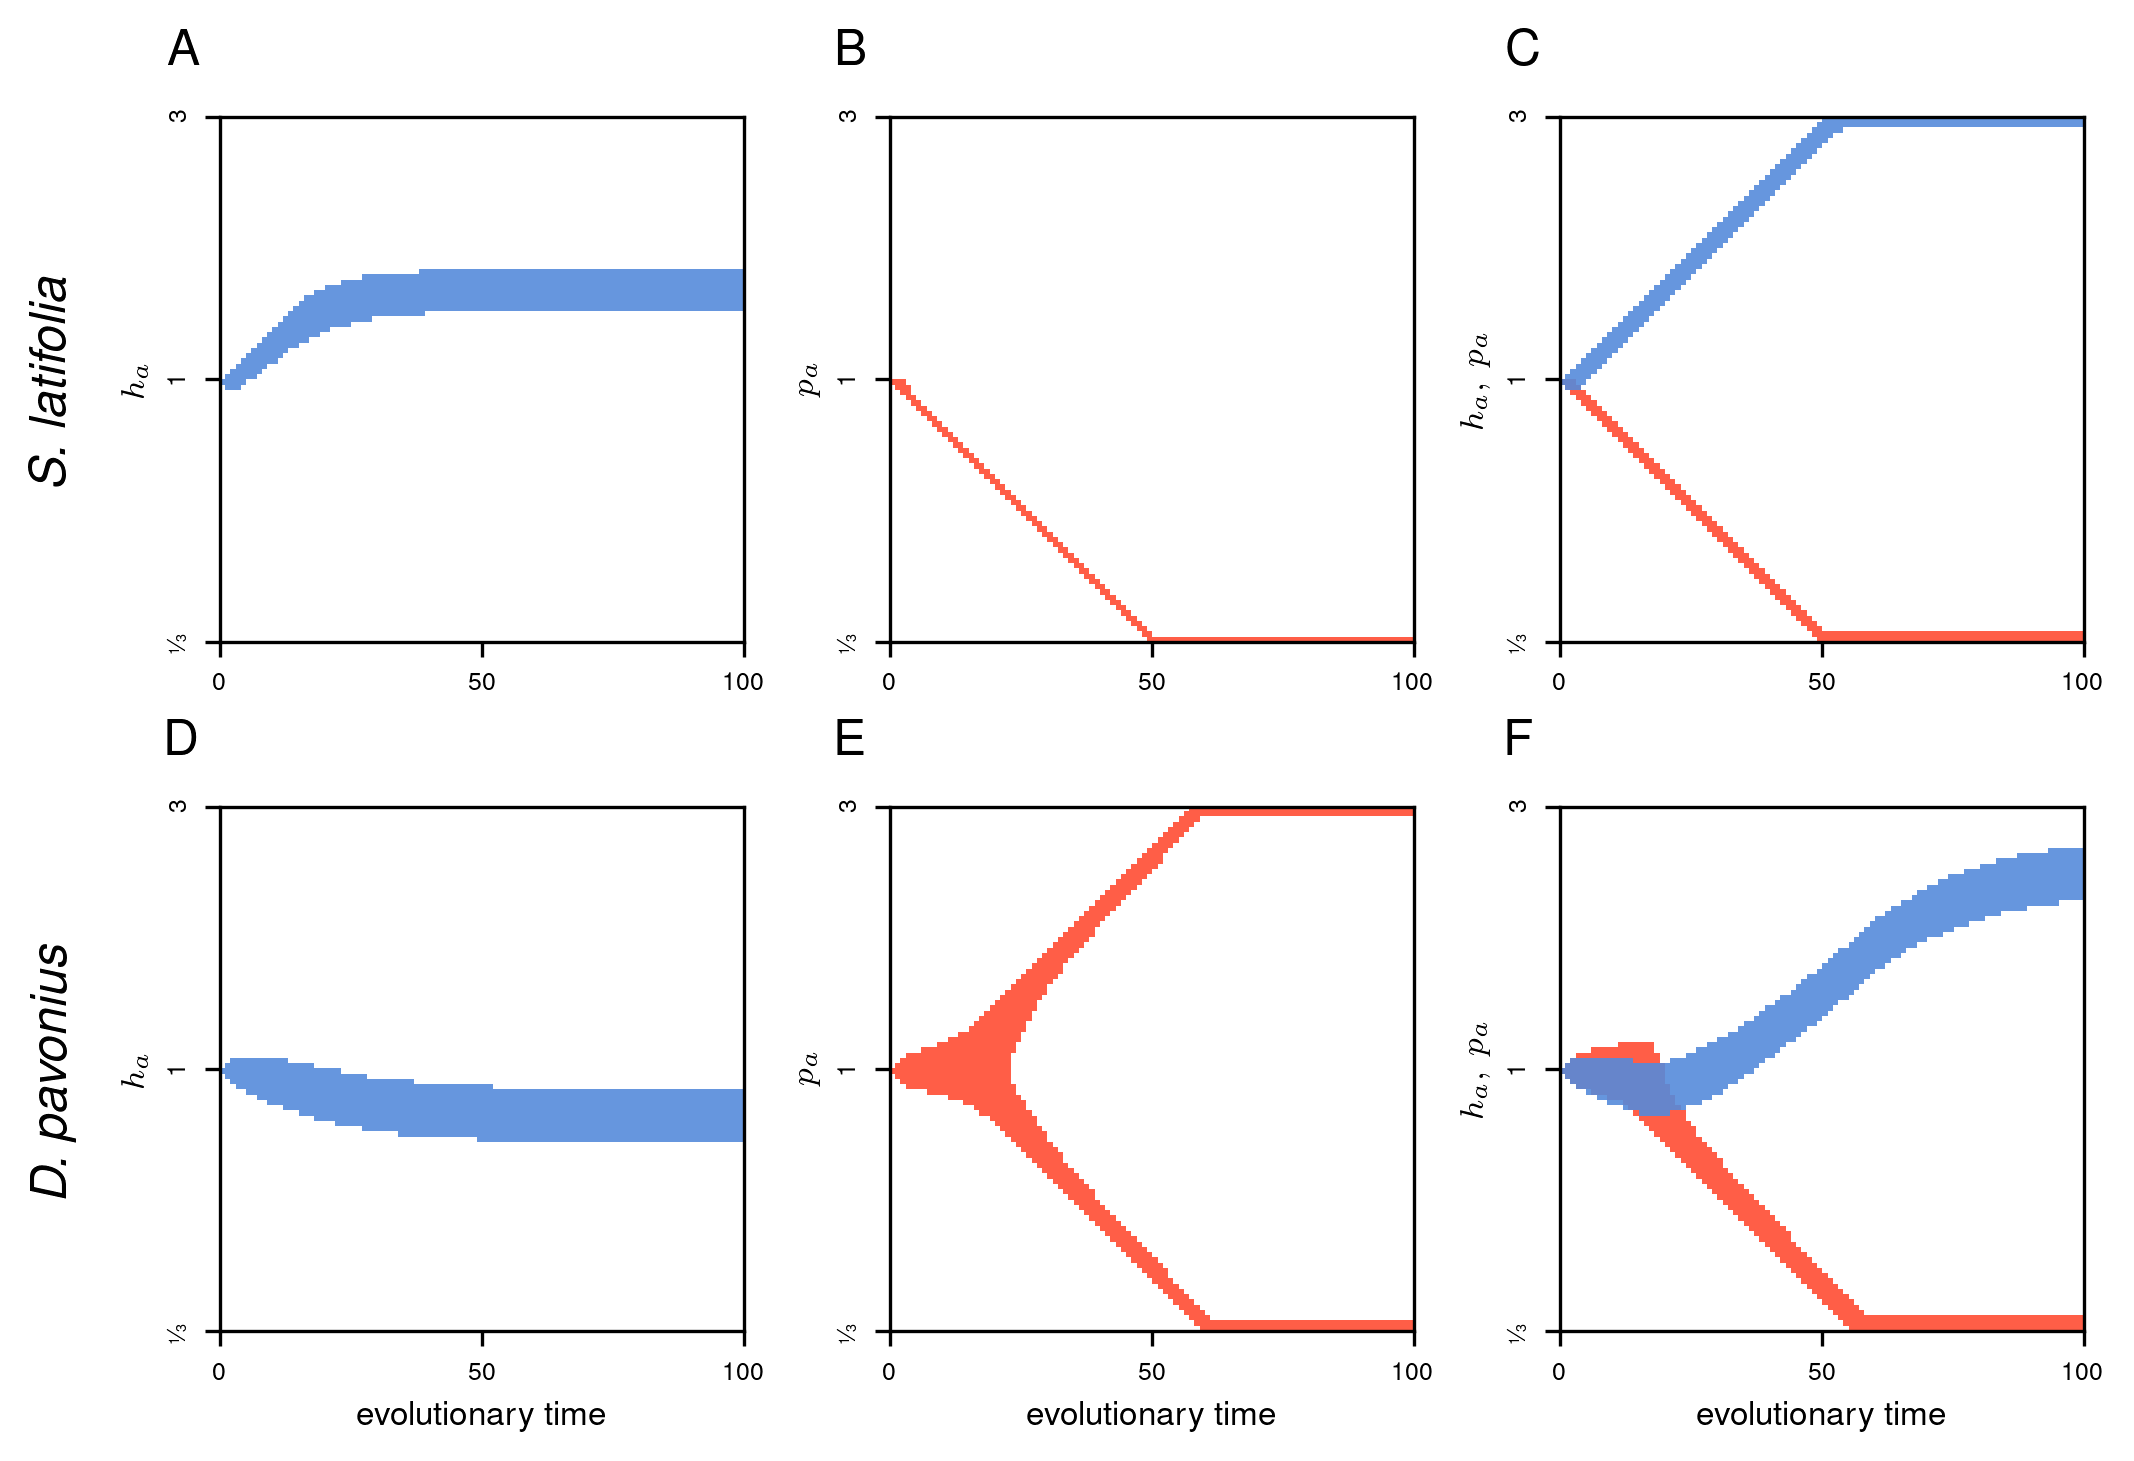

In [12]:
fig, ax = plt.subplots(figsize=(7,5), ncols=3, nrows=2, layout='compressed')

def make_image(Sa, Ia):
    Sa_img = Sa / np.max(Sa)
    Ia_img = Ia / np.max(Ia)
    Sa_img = np.array(Image.fromarray(Sa).resize(size=(100,100)))
    Ia_img = np.array(Image.fromarray(Ia).resize(size=(100,100)))
    Sa_img[Sa_img >= 0.2] = 1
    Sa_img[Sa_img < 0.2] = 0
    Ia_img[Ia_img >= 0.2] = 1
    Ia_img[Ia_img < 0.2] = 0

    Sa_alpha = np.ones(Sa_img.shape)*0.9
    Ia_alpha = np.ones(Ia_img.shape)*0.9
    Sa_alpha[Sa_img == 0] = 0
    Ia_alpha[Ia_img == 0] = 0

    return (Sa_img, Ia_img, Sa_alpha, Ia_alpha)

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, latifolia_model_h.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

Sa_img_lat_h, Ia_img_lat_h, Sa_alpha_lat_h, Ia_alpha_lat_h = make_image(latifolia_model_h.Sa, latifolia_model_h.Ia)
Sa_img_lat_p, Ia_img_lat_p, Sa_alpha_lat_p, Ia_alpha_lat_p = make_image(latifolia_model_p.Sa, latifolia_model_p.Ia)
Sa_img_lat_c, Ia_img_lat_c, Sa_alpha_lat_c, Ia_alpha_lat_c = make_image(latifolia_model_c.Sa, latifolia_model_c.Ia)

Sa_img_pav_h, Ia_img_pav_h, Sa_alpha_pav_h, Ia_alpha_pav_h = make_image(pavonius_model_h.Sa, pavonius_model_h.Ia)
Sa_img_pav_p, Ia_img_pav_p, Sa_alpha_pav_p, Ia_alpha_pav_p = make_image(pavonius_model_p.Sa, pavonius_model_p.Ia)
Sa_img_pav_c, Ia_img_pav_c, Sa_alpha_pav_c, Ia_alpha_pav_c = make_image(pavonius_model_c.Sa, pavonius_model_c.Ia)

ax[0,0].imshow(Sa_img_lat_h, alpha=Sa_alpha_lat_h, cmap=s_cmap)
ax[0,1].imshow(Ia_img_lat_p, alpha=Ia_alpha_lat_p, cmap=i_cmap)
ax[0,2].imshow(Ia_img_lat_c, alpha=Ia_alpha_lat_c, cmap=i_cmap)
ax[0,2].imshow(Sa_img_lat_c, alpha=Sa_alpha_lat_c, cmap=s_cmap)

ax[1,0].imshow(Sa_img_pav_h, alpha=Sa_alpha_pav_h, cmap=s_cmap)
ax[1,1].imshow(Ia_img_pav_p, alpha=Ia_alpha_pav_p, cmap=i_cmap)
ax[1,2].imshow(Ia_img_pav_c, alpha=Ia_alpha_pav_c, cmap=i_cmap)
ax[1,2].imshow(Sa_img_pav_c, alpha=Sa_alpha_pav_c, cmap=s_cmap)

ax_tick_pos = np.linspace(ax[0,0].get_ylim()[0], ax[0,0].get_ylim()[1], 3)
ax_tick_labels = [r'\sfrac{1}{3}',r'1',r'3']

for axis in ax.reshape(-1): 
    axis.set_yticks(ax_tick_pos, ax_tick_labels, rotation=90)
    label_x_axis(axis)

ax[0,0].set_ylabel(r'$h_a$')
ax[0,1].set_ylabel(r'$p_a$')
ax[0,2].set_ylabel(r'$h_a,\ p_a$')

ax[1,0].set_ylabel(r'$h_a$')
ax[1,1].set_ylabel(r'$p_a$')
ax[1,2].set_ylabel(r'$h_a,\ p_a$')

for axis in ax[1,:]: 
    axis.set_xlabel(r'evolutionary time')

ax[0,0].annotate(r'\textit{S. latifolia}', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)
ax[1,0].annotate(r'\textit{D. pavonius}', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

Text(-0.1, 1.1, 'F')

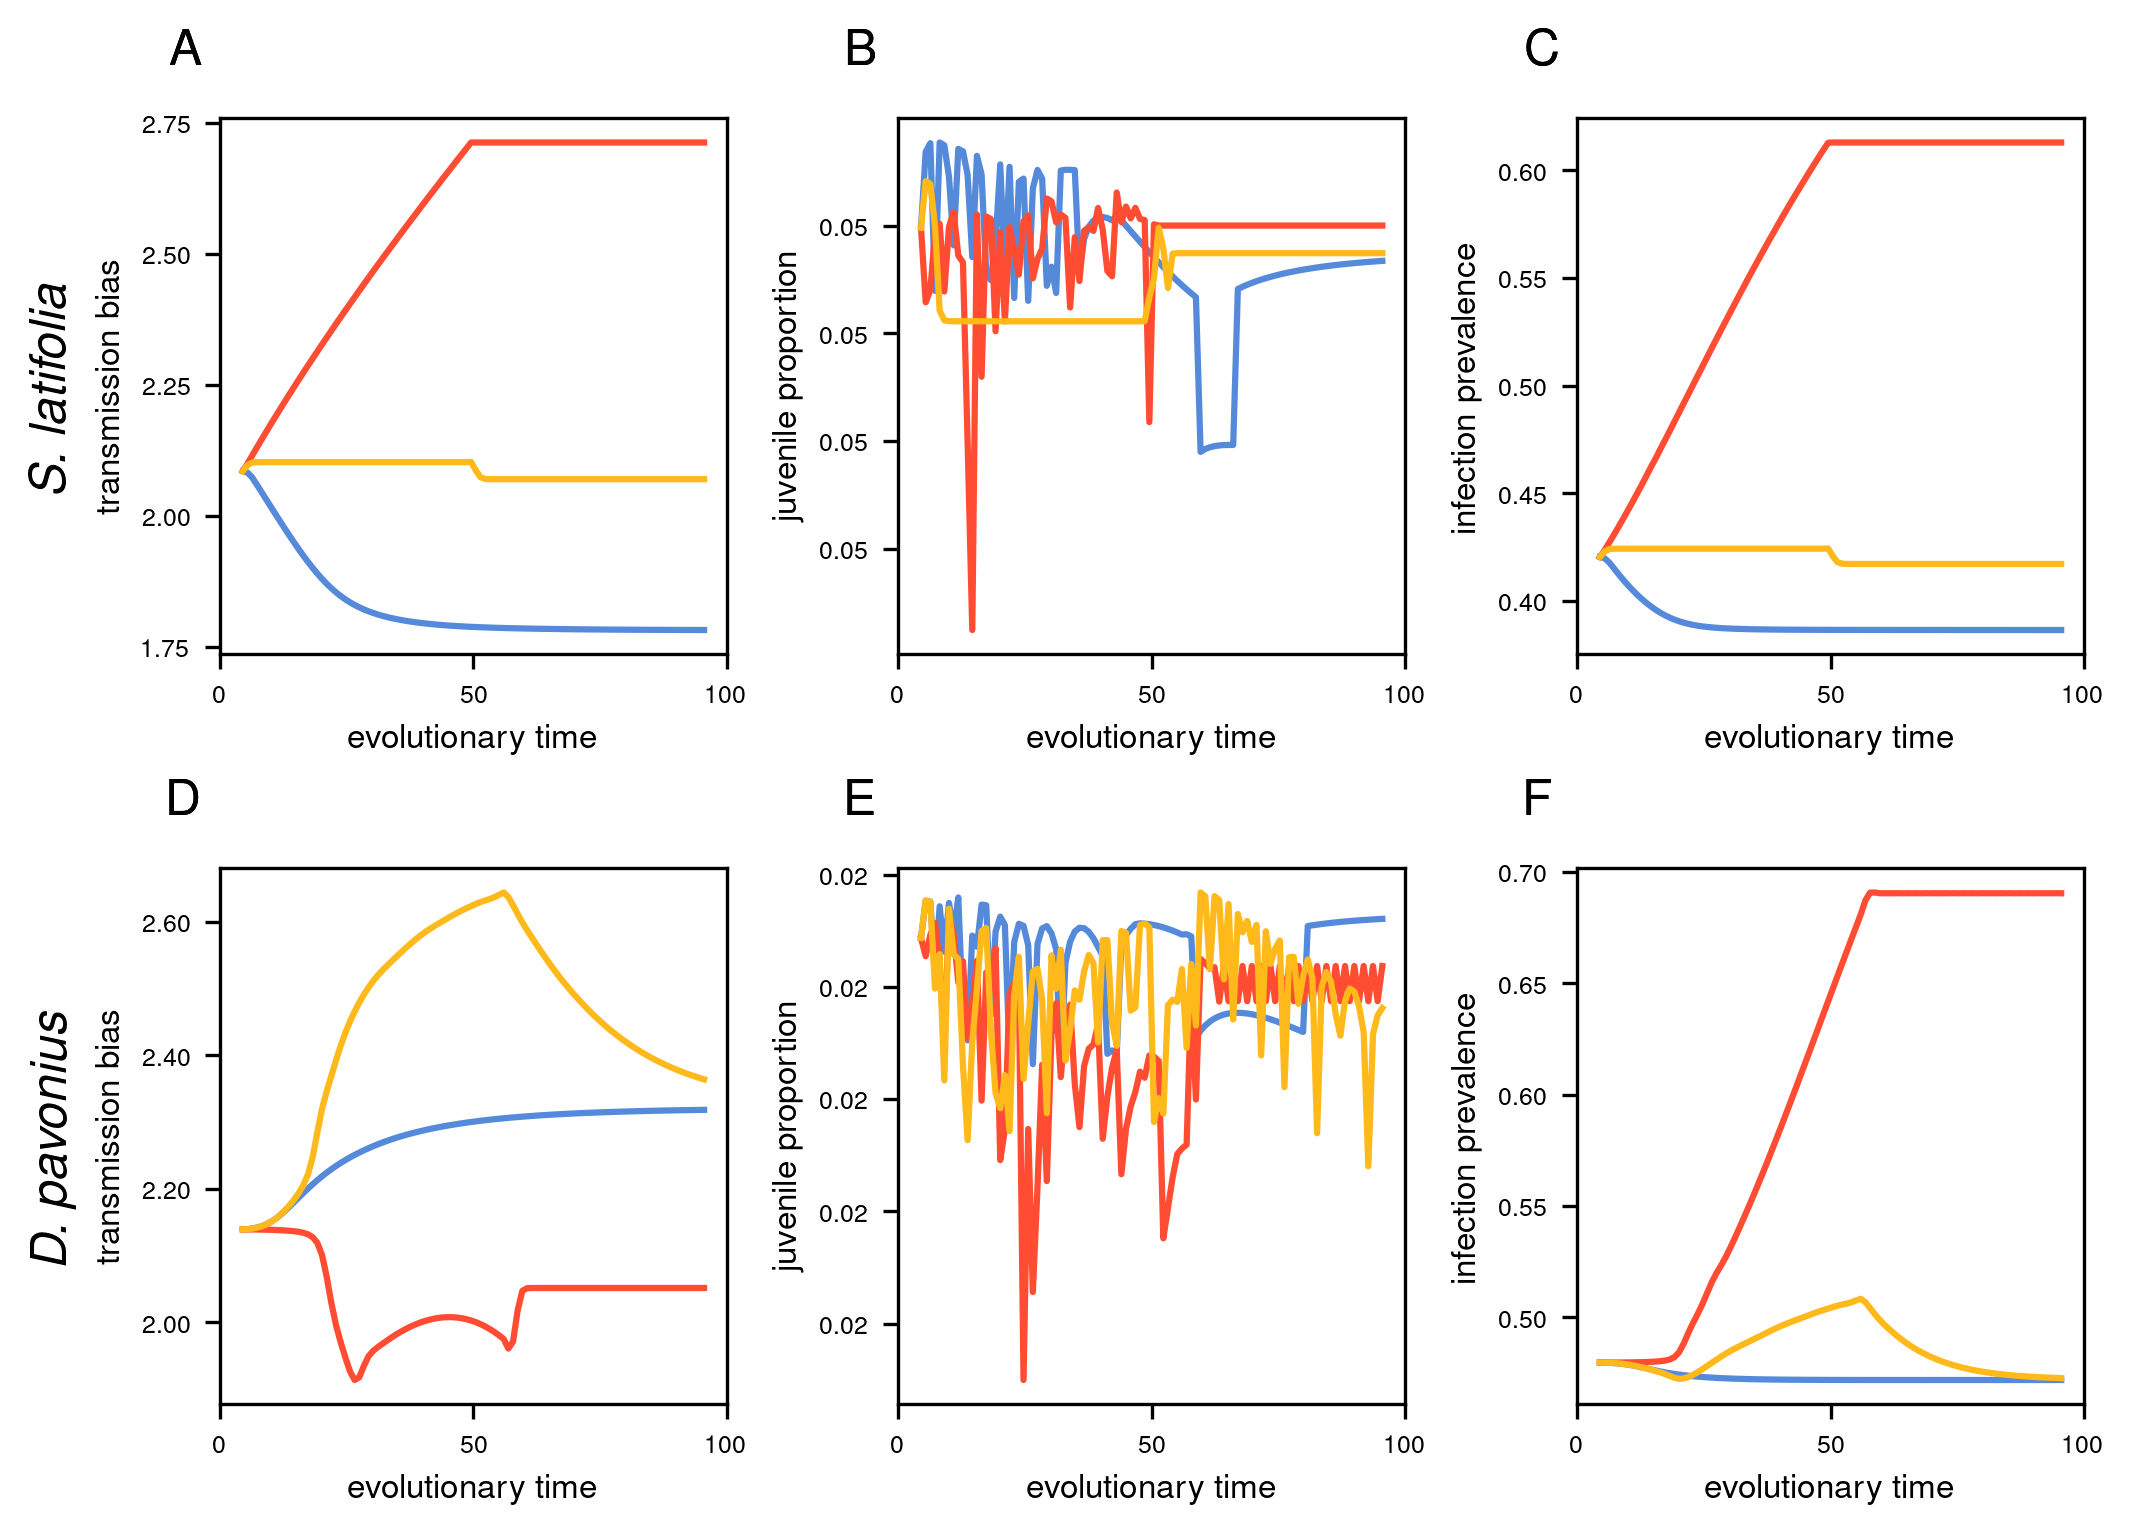

In [13]:
fig, ax = plt.subplots(figsize=(7,5), ncols=3, nrows=2, layout='compressed')

def label_x_axis(ax, n_x_ticks = 3):
    x_lim = ax.get_xlim()
    x_ticks = np.linspace(x_lim[0], x_lim[1], n_x_ticks)
    x_tick_labels = np.linspace(0, latifolia_model_h.N_iter, n_x_ticks)

    ax.set_xticks(x_ticks, x_tick_labels.astype(int))

ax[0,0].plot(latifolia_model_h.foi_bias(), label='host', color=host_color)
ax[0,0].plot(latifolia_model_p.foi_bias(), label='pathogen', color=path_color)
ax[0,0].plot(latifolia_model_c.foi_bias(), label='coevolution', color=coevol_color)

ax[0,1].plot(latifolia_model_h.juv_prop(), label='host', color=host_color)
ax[0,1].plot(latifolia_model_p.juv_prop(), label='pathogen', color=path_color)
ax[0,1].plot(latifolia_model_c.juv_prop(), label='coevolution', color=coevol_color)

ax[0,2].plot(latifolia_model_h.inf_prev(), label='host', color=host_color)
ax[0,2].plot(latifolia_model_p.inf_prev(), label='pathogen', color=path_color)
ax[0,2].plot(latifolia_model_c.inf_prev(), label='coevolution', color=coevol_color)

ax[1,0].plot(pavonius_model_h.foi_bias(), label='host', color=host_color)
ax[1,0].plot(pavonius_model_p.foi_bias(), label='pathogen', color=path_color)
ax[1,0].plot(pavonius_model_c.foi_bias(), label='coevolution', color=coevol_color)

ax[1,1].plot(pavonius_model_h.juv_prop(), label='host', color=host_color)
ax[1,1].plot(pavonius_model_p.juv_prop(), label='pathogen', color=path_color)
ax[1,1].plot(pavonius_model_c.juv_prop(), label='coevolution', color=coevol_color)

ax[1,2].plot(pavonius_model_h.inf_prev(), label='host', color=host_color)
ax[1,2].plot(pavonius_model_p.inf_prev(), label='pathogen', color=path_color)
ax[1,2].plot(pavonius_model_c.inf_prev(), label='coevolution', color=coevol_color)

#ax[1,0].set_ylim(-0.5, 1.25)
#ax[1,1].set_ylim(0.2, 0.25)
#ax[1,2].set_ylim(0.35, 0.45)#

for axis in ax.reshape(-1): 
    axis.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(nbins=5))
    axis.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.2f'))
    label_x_axis(axis)
    axis.set_xlabel(r'evolutionary time')

ax[0,0].set_ylabel(r'transmission bias')
ax[0,1].set_ylabel(r'juvenile proportion')
ax[0,2].set_ylabel(r'infection prevalence')
ax[1,0].set_ylabel(r'transmission bias')
ax[1,1].set_ylabel(r'juvenile proportion')
ax[1,2].set_ylabel(r'infection prevalence')

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

for axis in ax[1,:]: 
    axis.set_xlabel(r'evolutionary time')

ax[0,0].annotate(r'\textit{S. latifolia}', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)
ax[1,0].annotate(r'\textit{D. pavonius}', xy=(0, 0.5), xytext=(-40,0), xycoords='axes fraction', textcoords='offset points', ha='center', va='center', rotation=90, fontsize=axis_title_size)

ax[0,0].annotate("A", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,1].annotate("B", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[0,2].annotate("C", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,0].annotate("D", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,1].annotate("E", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)
ax[1,2].annotate("F", xy=(-0.1, 1.1), xycoords="axes fraction", fontsize=plot_label_size)

In [6]:
np.sum(latifolia_model_h.Ij[:,-1]) / (np.sum(latifolia_model_h.Ij[:,-1]) + np.sum(latifolia_model_h.Ia[:,-1]))

/tmp/ipykernel_9450/3167249161.py:1: RuntimeWarning: invalid value encountered in scalar divide
  np.sum(latifolia_model_h.Ij[:,-1]) / (np.sum(latifolia_model_h.Ij[:,-1]) + np.sum(latifolia_model_h.Ia[:,-1]))


np.float64(nan)